<a href="https://colab.research.google.com/github/SriVidyaYeluripati/mlph_w24/blob/main/sheet05/sheet05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sheet 5

In [ ]:
import os
import pandas as pd

## 2 Logistic regression: an LLM lie detector

Download the data from https://heibox.uni-heidelberg.de/f/38bd3f2a9b7944248cc2/   
Unzip it and place the lie_detection folder in the folder named `data` to get the following structure:
"data/lie_detection/datasets" and "data/lie_detection/acts".

This is how you can load a dataset of LLM activations. Use a new Datamanager if you want to have a new dataset. Use the same data manager if you want to combine datasets.

In [ ]:
from lie_detection_utils import DataManager

path_to_datasets = "data/lie_detection/datasets"
path_to_acts = "data/lie_detection/acts"

# check if the datasets and activations are available
assert os.path.exists(path_to_datasets), "The path to the datasets does not exist."
assert os.path.exists(path_to_acts), "The path to the activations does not exist."

# these are the different datasets containing true and false factual statements about different topics
dataset_names = ["cities", "neg_cities", "sp_en_trans", "neg_sp_en_trans"]
dataset_name = dataset_names[0] # choose some dataset from the above datasets, index "0" loads the "cities" dataset for example

# the dataloader automatically loads the training data for us
dm = DataManager()
dm.add_dataset(dataset_name, "Llama3", "8B", "chat", layer=12, split=0.8, center=False,
                device='cpu', path_to_datasets=path_to_datasets, path_to_acts=path_to_acts)
acts_train, labels_train = dm.get('train') # train set
acts_test, labels_test = dm.get('val')
print(acts_train.shape, labels_train.shape)

In [ ]:
# have a look at the statements that were fed to the LLM to produce the activations:
df = pd.read_csv(f"{path_to_datasets}/{dataset_name}.csv")
print(df.head(10))

## 3 Log-sum-exp and soft(arg)max
### (b)

### (c)

## 4 Linear regions of MLPs

Part (a)

In [4]:
import torch
import torch.nn as nn

torch.manual_seed(42)

class ShallowModel(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)  # Initialize the base neural network class

        # Hidden layer takes 2 inputs and sends to 20 neurons
        self.hidden_layer = nn.Linear(2, 20)  # Parameters: 2 inputs * 20 neurons + 20 biases = 40 weights + 20 biases = 60 parameters total

        # Output layer takes 20 inputs and sends to 1 output neuron
        self.output_layer = nn.Linear(20, 1)  # Parameters: 20 inputs * 1 output + 1 bias = 20 weights + 1 bias = 21 parameters total

    def forward(self, x):
        # Pass the input through the hidden layer and apply ReLU to keep only positive values
        x = torch.relu(self.hidden_layer(x))

        # Pass the result through the output layer to get the final value
        x = self.output_layer(x)

        return x

shallow_model = ShallowModel()
num_params = 0
for param in shallow_model.parameters():
    # If the parameter can be learned (i.e., updated during training)
    if param.requires_grad:

        num_params += param.numel()
print("The number of parameters in the model is:", num_params)  # Output: The number of parameters in the model is: 81


The number of parameters in the model is: 81


Part (b)

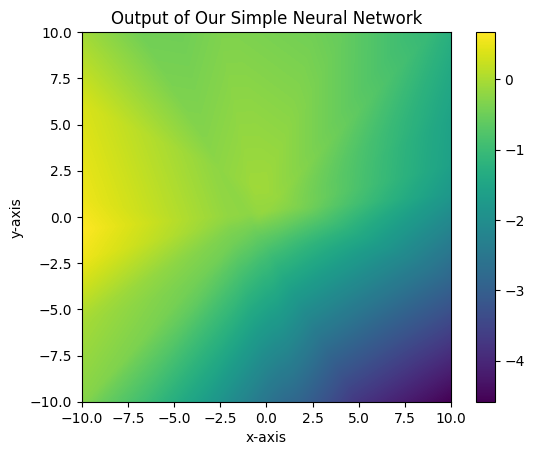

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Create a grid of x and y values from -10 to 10 (for both x and y axes)
x_values = np.linspace(-10, 10, 500)  # 500 evenly spaced values between -10 and 10 for the x-axis
y_values = np.linspace(-10, 10, 500)  # 500 evenly spaced values between -10 and 10 for the y-axis

# Create a grid from the x and y values
xx, yy = np.meshgrid(x_values, y_values)  # Meshgrid makes a grid of (x, y) points

# Flatten the grid to get a list of points (each point has an x and y value)
grid_points = np.c_[xx.ravel(), yy.ravel()]  # Create all possible combinations of x and y coordinates

# Convert grid points to a tensor that the network can work with
grid_tensor = torch.tensor(grid_points, dtype=torch.float32)  # Convert to a tensor for PyTorch

# Pass the grid through the model to get predictions
with torch.no_grad():  # We don't need to compute gradients, as we're not training
    output_values = shallow_model(grid_tensor).numpy()  # Pass through the shallow model we created and convert to numpy

# Reshape the output to match our original grid
output_values = output_values.reshape(xx.shape)  # Convert the output back to the grid shape


plt.imshow(output_values, extent=(-10, 10, -10, 10), origin='lower', cmap='viridis')
plt.colorbar()  # Add color bar to see the value ranges
plt.title("Output of Our Simple Neural Network")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.show()  # Display the plot


Part (C)

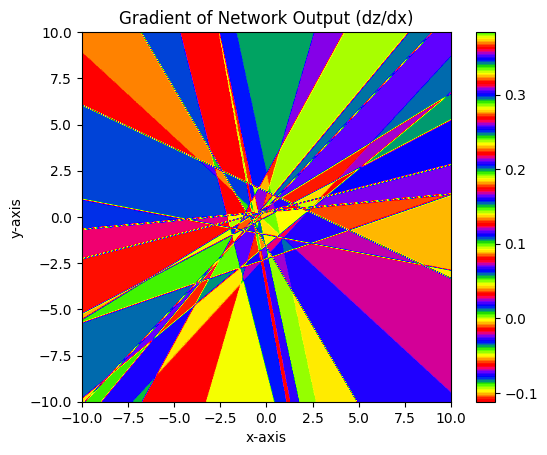

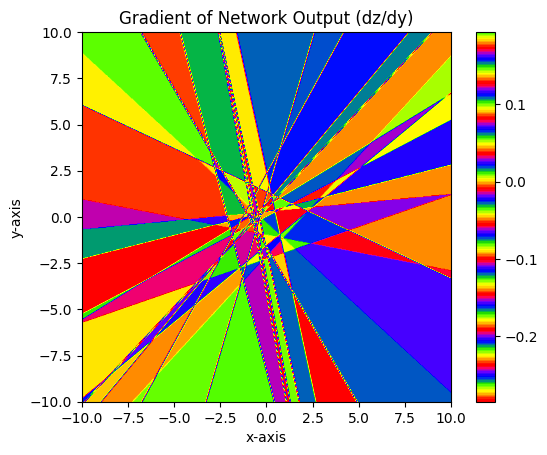

In [7]:
# Compute the gradient of the network output with respect to x and y
gradient_x, gradient_y = np.gradient(output_values, x_values, y_values)

# Plot how the output changes in the x direction
plt.imshow(gradient_x, extent=(-10, 10, -10, 10), origin='lower', cmap='prism')
plt.colorbar()
plt.title("Gradient of Network Output (dz/dx)")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.show()

# Plot how the output changes in the y direction
plt.imshow(gradient_y, extent=(-10, 10, -10, 10), origin='lower', cmap='prism')
plt.colorbar()
plt.title("Gradient of Network Output (dz/dy)")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.show()


Part (d)

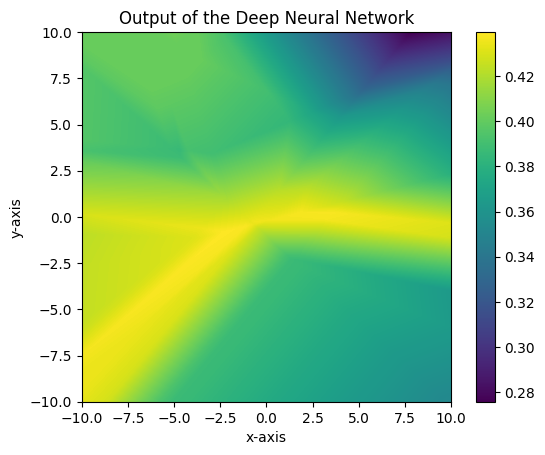

In [8]:
# Set seed for reproducibility
torch.manual_seed(42)

# Define a deeper model with four hidden layers
class DeepModel(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)

        # Create four hidden layers each with 5 neurons
        self.layer1 = nn.Linear(2, 5)  # Input to hidden layer 1
        self.layer2 = nn.Linear(5, 5)  # Hidden layer 1 to hidden layer 2
        self.layer3 = nn.Linear(5, 5)  # Hidden layer 2 to hidden layer 3
        self.layer4 = nn.Linear(5, 5)  # Hidden layer 3 to hidden layer 4
        self.output_layer = nn.Linear(5, 1)  # Hidden layer 4 to output

    def forward(self, x):
        x = torch.relu(self.layer1(x))  # Pass through layer 1 with ReLU
        x = torch.relu(self.layer2(x))  # Pass through layer 2 with ReLU
        x = torch.relu(self.layer3(x))  # Pass through layer 3 with ReLU
        x = torch.relu(self.layer4(x))  # Pass through layer 4 with ReLU
        x = self.output_layer(x)  # Final output
        return x

# Create an instance of the deeper model
deep_model = DeepModel()

# Pass the same grid through the deep model
with torch.no_grad():
    output_values_deep = deep_model(grid_tensor).numpy()

# Reshape the output to match the grid
output_values_deep = output_values_deep.reshape(xx.shape)

# Plot the output as an image
plt.imshow(output_values_deep, extent=(-10, 10, -10, 10), origin='lower', cmap='viridis')
plt.colorbar()
plt.title("Output of the Deep Neural Network")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.show()
